# Imports

In [ ]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
from preprocessing import *
import tensorflow as tf
import ast
from tensorflow.keras.models import load_model
from explainability import *

# loading model and data

In [17]:
model = load_model("..\models\model_0.01_32.keras")

In [ ]:
path_metadata = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\ptbxl_database.csv"
#path_metadata = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptbxl_database.csv"
sampling_rate = 100 #500
main_path = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\" #\\records"+str(sampling_rate)
#main_path = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\"

In [7]:
#loadidng metadata
metadata_all_df = pd.read_csv(path_metadata, index_col='ecg_id')
metadata_all_df.scp_codes = metadata_all_df.scp_codes.apply(lambda x: ast.literal_eval(x))

In [8]:
#loading raw signal data
ecg_data = load_raw_data(metadata_all_df, sampling_rate, main_path)

In [9]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(main_path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [11]:
# Apply diagnostic superclass
metadata_all_df['diagnostic_superclass'] = metadata_all_df.scp_codes.apply(aggregate_diagnostic)

In [14]:
mask = metadata_all_df["diagnostic_superclass"].isin([["NORM"], ["MI"]])

metadata = metadata_all_df[mask].copy()
X = ecg_data[mask]

metadata["label"] = (
    metadata["diagnostic_superclass"].apply(lambda x: x == ["MI"])
).astype(int)

train, val, test = split_ds(X, metadata)

raw_xtrain, ytrain = train
raw_xval, yval = val
raw_xtest, ytest = test

processed_xtrain = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtrain
])

processed_xval = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xval
])

processed_xtest = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtest
])

X_train, X_val, X_test, scaler = standardize_signals(
    processed_xtrain,
    processed_xval,
    processed_xtest
)

# explaining

## saliency maps

In [38]:
mi_cases = ytest["label"].values == 1
mi_cases_x = X_test[mi_cases]
mi_cases_y = ytest[mi_cases]

In [49]:
mi_cases_x[0].shape

(1000, 12)

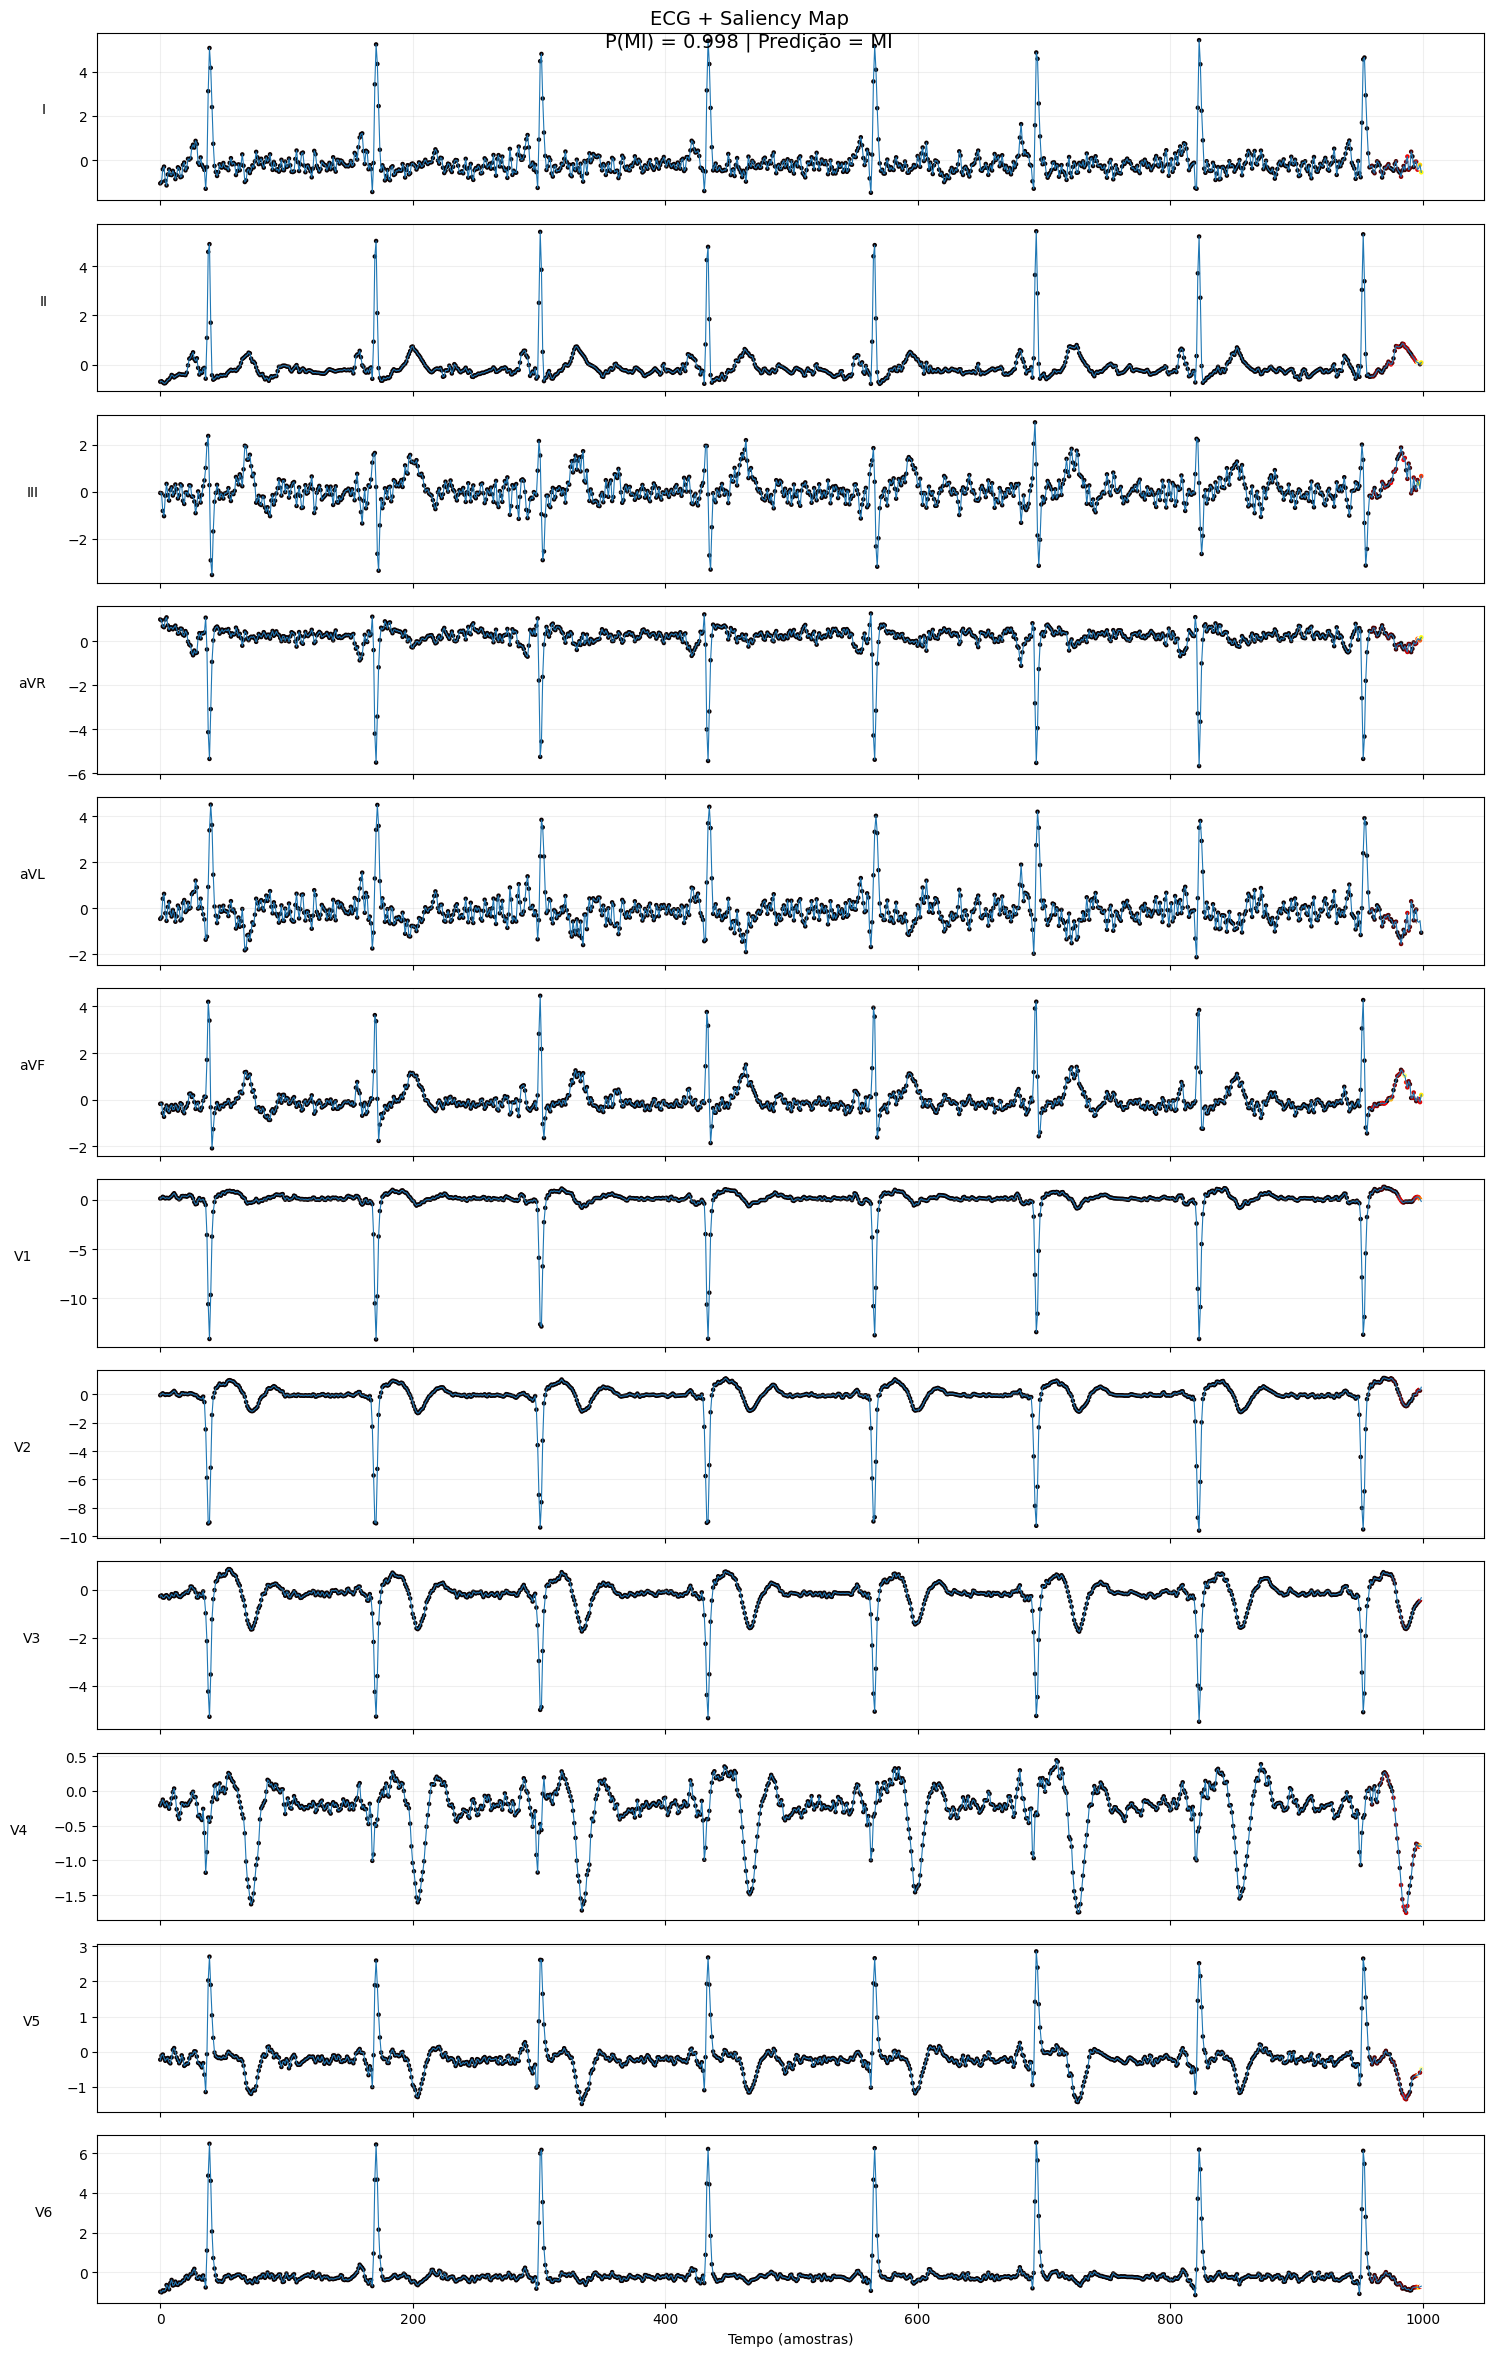

In [56]:
plot_ecg_saliency(model, mi_cases_x[100])

## gradcam

1/1 [==============================] - 0s 234ms/step


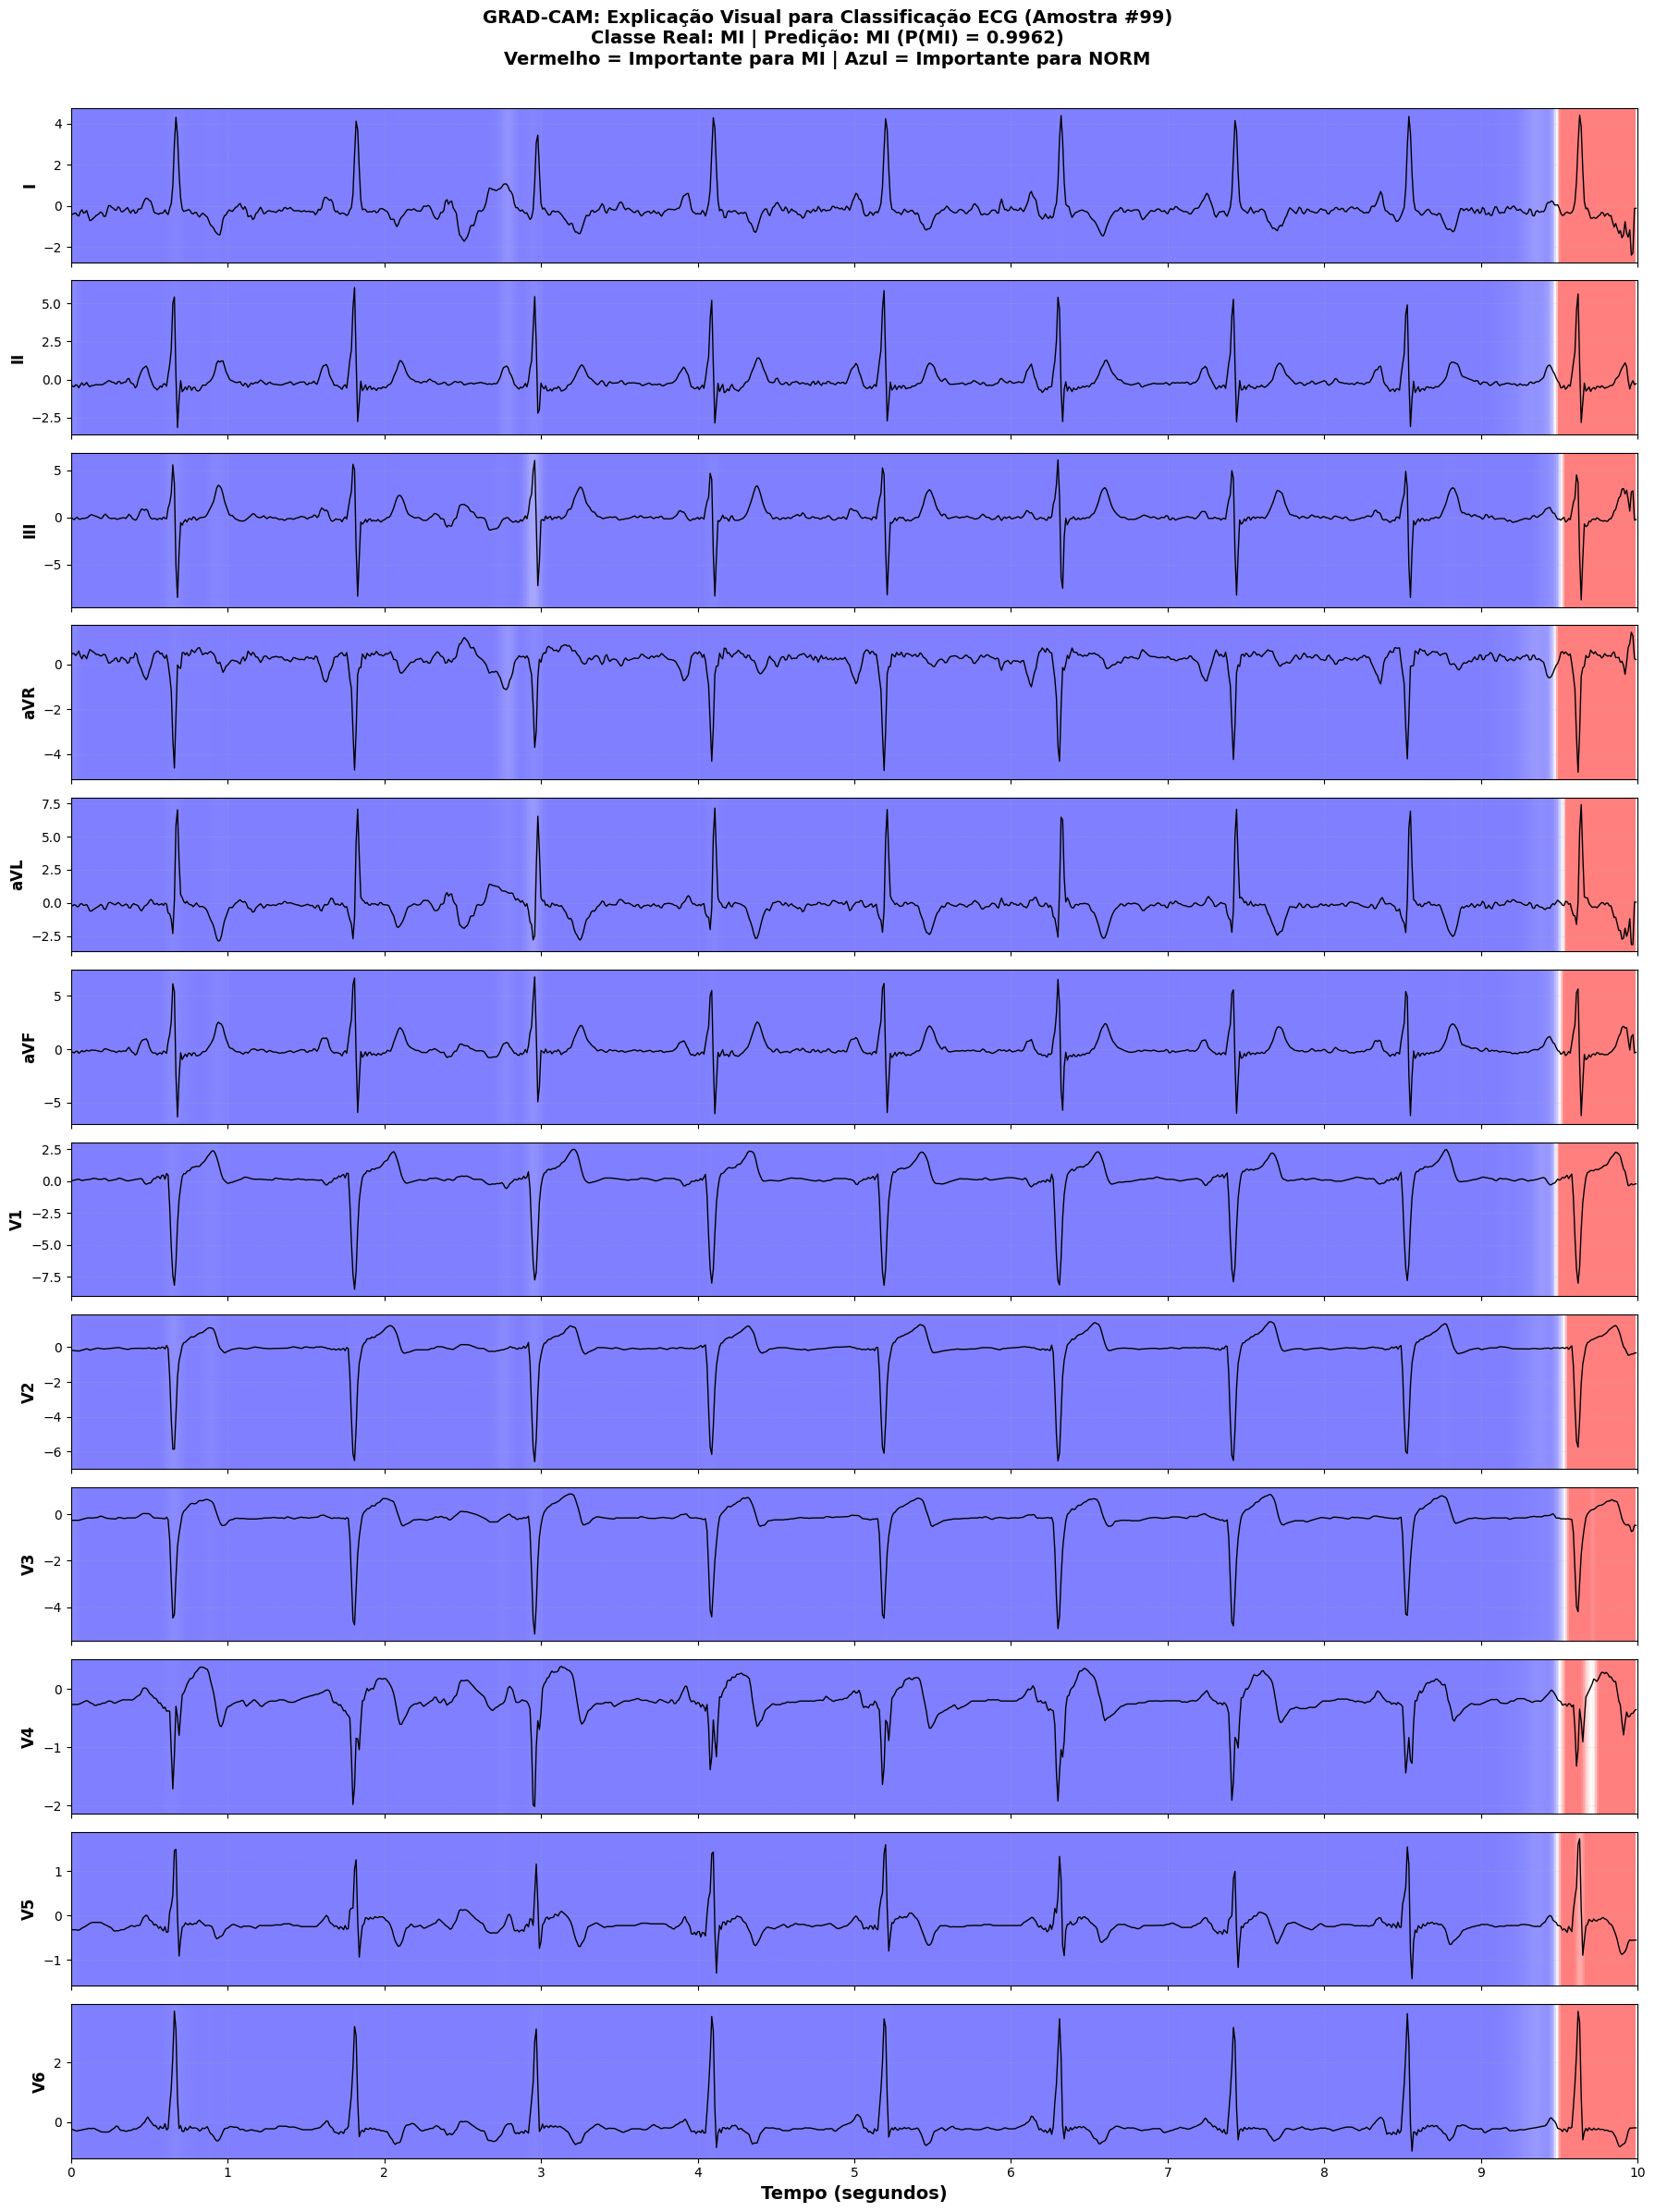

In [99]:
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
i=99
heatmap, edge_mask = get_gradcam_improved(
    model,
    np.expand_dims(mi_cases_x[i], axis=0),
    class_idx=1,
    smoothing="gaussian",
    smooth_sigma=3.0,
    edge_handling="trim",
    trim_percent=0.05,
    normalize_method="global"
)

plot_ecg_with_gradcam(
    mi_cases_x[i],
    heatmap,
    1,
    float(model.predict(np.expand_dims(mi_cases_x[i], axis=0))[0,0]),
    i,
    lead_names=lead_names
)



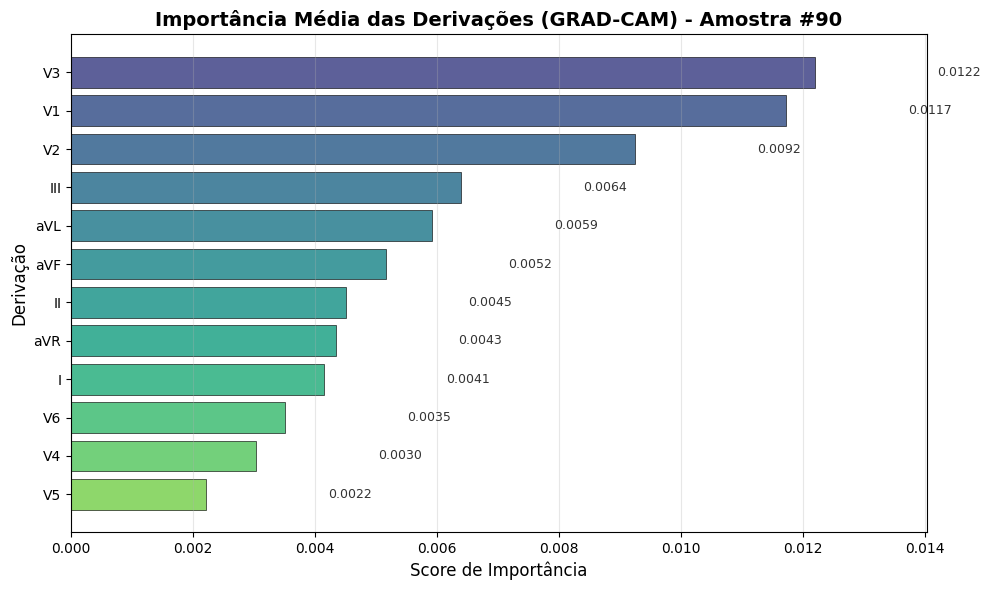

,Lead,Importance
8,V3,0.012198
6,V1,0.011713
7,V2,0.009240
2,III,0.006398
4,aVL,0.005923
5,aVF,0.005157
1,II,0.004509
3,aVR,0.004341
0,I,0.004147
11,V6,0.003507


In [91]:
plot_lead_importance_ranking(heatmap, i, lead_names)

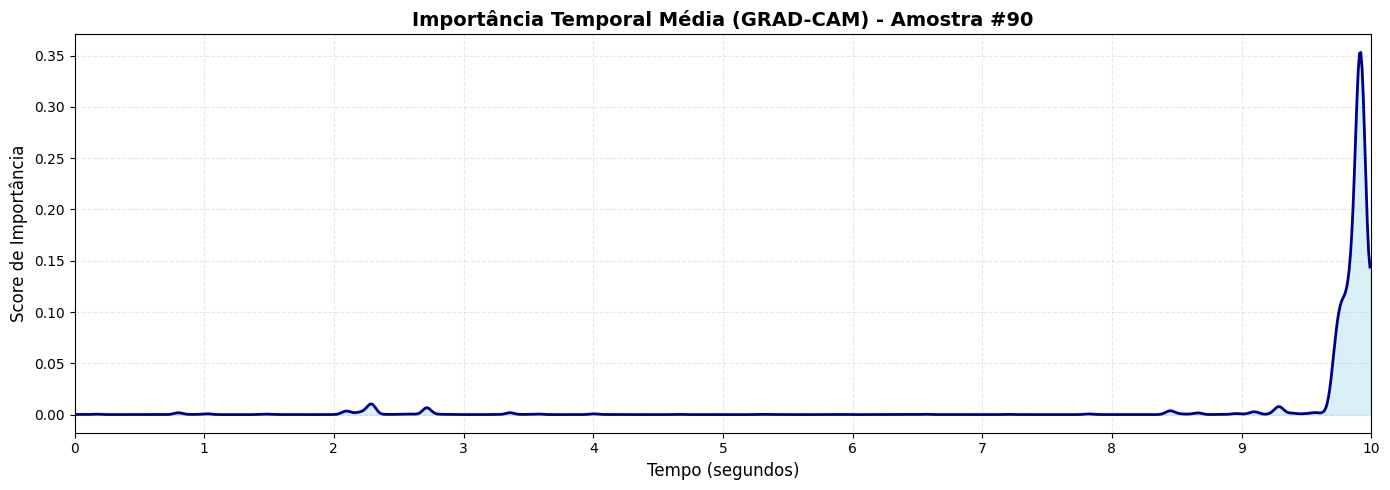

In [93]:
plot_temporal_importance(heatmap, i)